In [ ]:
#setup 

import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import os

if not os.path.exists('./dc_img'):
    os.mkdir('./dc_img')
    
print ("setup done")

setup done


In [14]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

In [15]:
#hyperparameters
num_epochs = 100
batch_size = 128
learning_rate = 1e-3

In [16]:
#Data loading
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

dataset = MNIST('./data', transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Number of batches:", len(dataloader))



Number of batches: 469


In [17]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [18]:
#Model definition
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),  # b, 16, 5, 5
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)  # b, 8, 2, 2
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2),  # b, 16, 5, 5
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 5, stride=3, padding=1),  # b, 8, 15, 15
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 2, stride=2, padding=1),  # b, 1, 28, 28
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

print ("model defined")


model defined


In [19]:
#Model and optimizer
model = autoencoder()

# load model if exists, after finalizing on the model, this can be used.
#if os.path.exists("conv_autoencoder.pth"):
    #model.load_state_dict(torch.load("conv_autoencoder.pth"))
    #print("Loaded previous model weights")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                             weight_decay=1e-5)

In [20]:
#visualize of noise and denoising.
# using noise of 0.3, strong noise to test quality of reconstruction
def visualize(model, dataloader, epoch, sigma=0.3):
    img, _ = next(iter(dataloader))

    noisy_img = add_noise(img, sigma)

    # no_grad (forward pass only,since we are using the resulted weights)
    with torch.no_grad():
        output = model(noisy_img)

    orig = to_img(img)
    noisy = to_img(noisy_img)
    recon = to_img(output)

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(orig[0][0], cmap='gray') #plot first image in batch

    plt.subplot(1,3,2)
    plt.title(f"Noisy σ={sigma}")
    plt.imshow(noisy[0][0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    plt.imshow(recon[0][0], cmap='gray')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

epoch [1/100], loss:128.5525


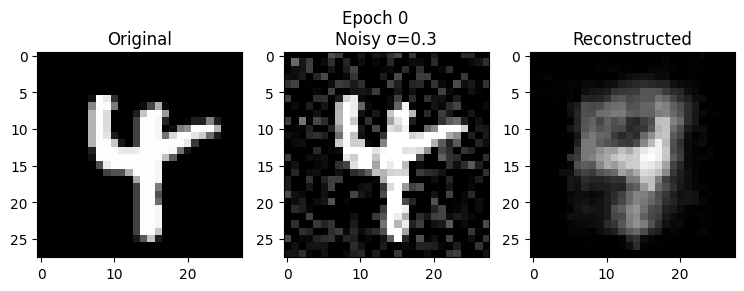

epoch [2/100], loss:86.3863
epoch [3/100], loss:73.3138
epoch [4/100], loss:67.4087
epoch [5/100], loss:64.0484
epoch [6/100], loss:61.3024
epoch [7/100], loss:59.0655
epoch [8/100], loss:57.6314
epoch [9/100], loss:56.4498
epoch [10/100], loss:55.7249
epoch [11/100], loss:55.1292


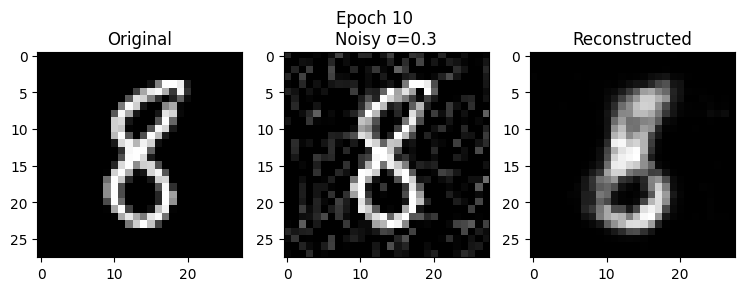

epoch [12/100], loss:54.3952
epoch [13/100], loss:53.8021
epoch [14/100], loss:53.4002
epoch [15/100], loss:52.9793
epoch [16/100], loss:52.5920
epoch [17/100], loss:52.2705
epoch [18/100], loss:51.9871
epoch [19/100], loss:51.6224
epoch [20/100], loss:51.4800
epoch [21/100], loss:51.1689


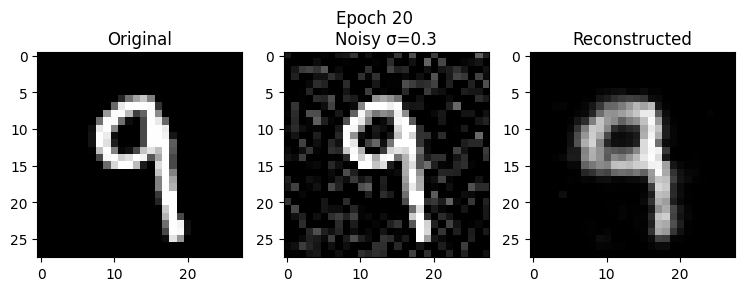

epoch [22/100], loss:50.9878
epoch [23/100], loss:50.7219
epoch [24/100], loss:50.5714
epoch [25/100], loss:50.4031
epoch [26/100], loss:50.2852
epoch [27/100], loss:50.1293
epoch [28/100], loss:49.9111
epoch [29/100], loss:49.6669
epoch [30/100], loss:49.5369
epoch [31/100], loss:49.4046


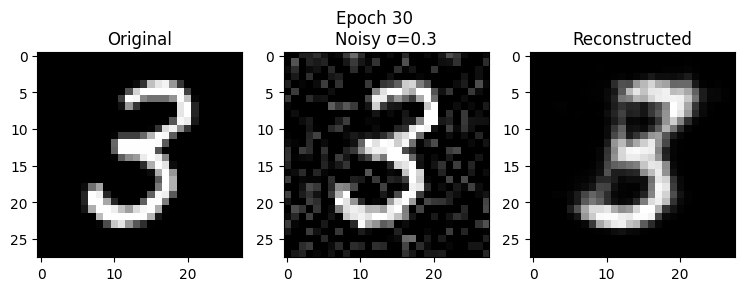

epoch [32/100], loss:49.4178
epoch [33/100], loss:49.4262
epoch [34/100], loss:49.2433
epoch [35/100], loss:49.0459
epoch [36/100], loss:49.0166
epoch [37/100], loss:48.8911
epoch [38/100], loss:48.7947
epoch [39/100], loss:48.7180
epoch [40/100], loss:48.5942
epoch [41/100], loss:48.6488


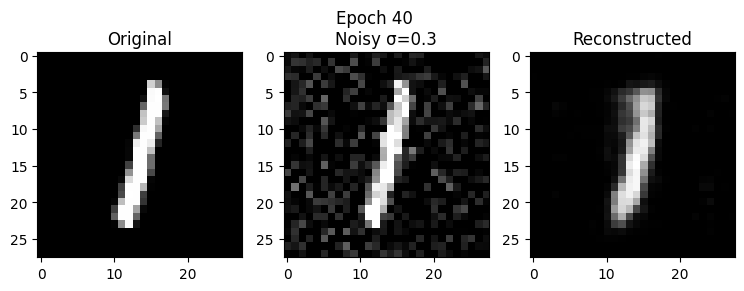

epoch [42/100], loss:48.5014
epoch [43/100], loss:48.4606
epoch [44/100], loss:48.4864
epoch [45/100], loss:48.2997
epoch [46/100], loss:48.2695
epoch [47/100], loss:48.2331
epoch [48/100], loss:48.0882
epoch [49/100], loss:48.1309
epoch [50/100], loss:48.0966
epoch [51/100], loss:48.0944


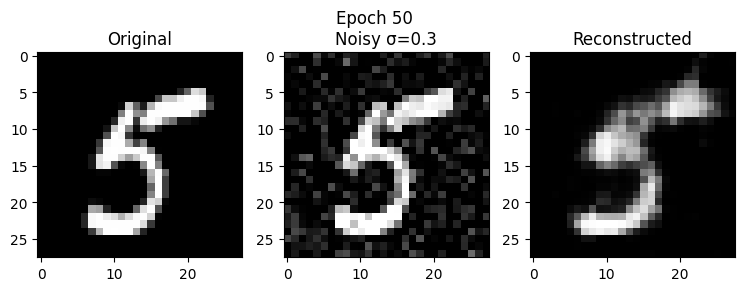

epoch [52/100], loss:47.8991
epoch [53/100], loss:47.8243
epoch [54/100], loss:47.9261
epoch [55/100], loss:47.7385
epoch [56/100], loss:47.8254
epoch [57/100], loss:47.6612
epoch [58/100], loss:47.6205
epoch [59/100], loss:47.6407
epoch [60/100], loss:47.5161
epoch [61/100], loss:47.3428


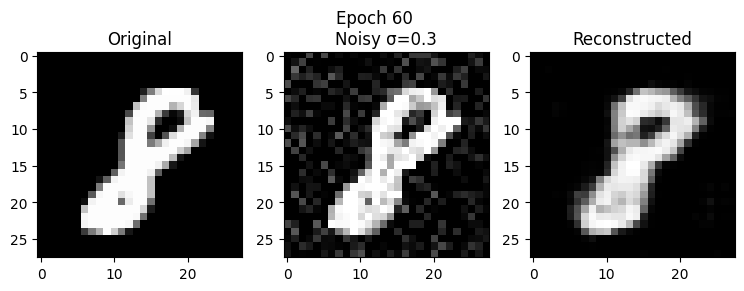

epoch [62/100], loss:47.3682
epoch [63/100], loss:47.2732
epoch [64/100], loss:47.2412
epoch [65/100], loss:47.1126
epoch [66/100], loss:47.2124
epoch [67/100], loss:47.0936
epoch [68/100], loss:47.1375
epoch [69/100], loss:46.9818
epoch [70/100], loss:46.9899
epoch [71/100], loss:46.9125


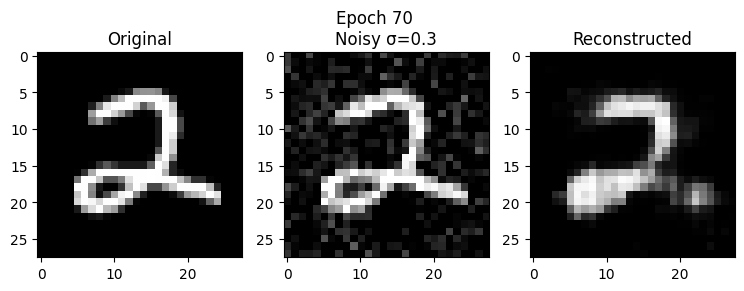

epoch [72/100], loss:46.8653
epoch [73/100], loss:46.8478
epoch [74/100], loss:46.7437
epoch [75/100], loss:46.5796
epoch [76/100], loss:46.4938
epoch [77/100], loss:46.6216
epoch [78/100], loss:46.6505
epoch [79/100], loss:46.5578
epoch [80/100], loss:46.4271
epoch [81/100], loss:46.4027


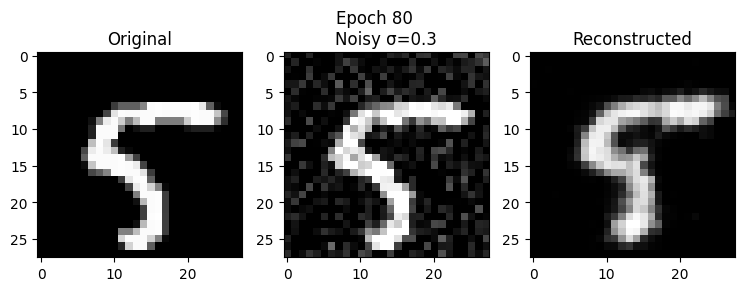

epoch [82/100], loss:46.3766
epoch [83/100], loss:46.3663
epoch [84/100], loss:46.2781
epoch [85/100], loss:46.3469
epoch [86/100], loss:46.4228
epoch [87/100], loss:46.1804
epoch [88/100], loss:46.1645
epoch [89/100], loss:46.1782
epoch [90/100], loss:46.1821
epoch [91/100], loss:46.0284


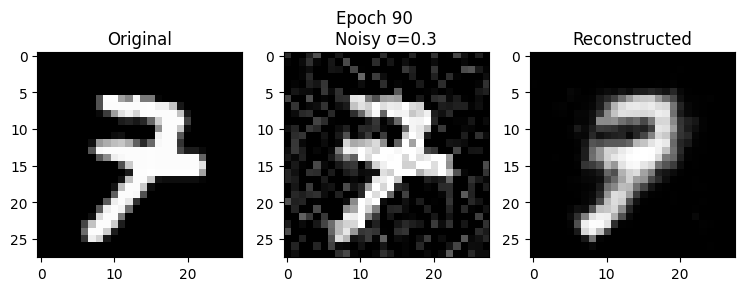

epoch [92/100], loss:46.0876
epoch [93/100], loss:45.8121
epoch [94/100], loss:45.9910
epoch [95/100], loss:45.9693
epoch [96/100], loss:45.8535
epoch [97/100], loss:45.9401
epoch [98/100], loss:45.8453
epoch [99/100], loss:45.9178
epoch [100/100], loss:45.8576


In [21]:
#Training loop
for epoch in range(num_epochs):
    total_loss = 0
    for data in dataloader:
        img, _ = data
        img = Variable(img)
        sigma = random.choice([0.1, 0.2, 0.3])
        noisy_img = add_noise(img, sigma=sigma)
        # ===================forward=====================
        output = model(noisy_img)
        loss = criterion(output, img)
        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.data
    # ===================log========================
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch+1, num_epochs, total_loss))
    if epoch % 10 == 0:
        visualize(model, dataloader, epoch) # visualize every 10 epochs
        pic = to_img(output.cpu().data)
        save_image(pic, './dc_img/image_{}.png'.format(epoch)) #saves images from the batch (recosntructed images) in a grid layout

In [22]:
#save model
torch.save(model.state_dict(), './conv_autoencoder.pth')